# ETF risk overlays: what a stop costs when the holding period is a month

A risk overlay is a rule that closes a position before the strategy would have. A stop-loss
closes it when it has lost a fixed amount, a trailing stop when it has given back a fixed amount
of its gain, a time exit when it has been held long enough. Each is uncontroversial as an idea
and each does the same thing to the return distribution: it removes the left tail and, because it
cannot tell which is which, part of the right one too.

**The reason this is a real question here and not a formality is the rebalancing cadence.** This
strategy holds a fund for a month and then re-ranks. A stop that fires on day nine has not
avoided a month of loss; it has ended a position nine days early and left the capital idle until
the rebalance that would have closed the position anyway. Whether that helps depends entirely on
what the fund did over the remaining days, which is the thing nobody knows at the time.

So the overlay grid spans thresholds from very tight to very loose, and the tight end is expected
to fire on ordinary intra-month movement rather than on anything the strategy should react to.
Where the grid turns from harmful to harmless is what this notebook is for.

**Learning objectives**

- Say what a position-level risk rule does to both tails of a return distribution, not only the
  left one.
- Say why a rule's trigger frequency has to be read against the strategy's holding period.
- Calibrate a trailing threshold from the observed adverse-excursion distribution rather than
  from a round number, and say what that changes.
- Read a risk overlay against its own baseline rather than against zero.

**Book reference**: Chapter 19, Sections 19.3 to 19.6.

**Prerequisites**: [`15_portfolio_management`](15_portfolio_management.ipynb), whose allocation
stage supplies the combinations the overlays are applied to.

**What it writes**: one row in `backtest_runs` per combination and risk control, at
`stage='risk_overlay'`. [`18_strategy_analysis`](18_strategy_analysis.ipynb) reads the whole
pipeline, this stage included.

In [1]:
"""Apply position and portfolio risk overlays to the leading ETF allocation combinations."""

import json
import time
import warnings

import plotly.graph_objects as go
import polars as pl

from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.backtest_loaders import (
    VECTORIZED_CASE_STUDIES,
    get_backtest_config,
    load_backtest_prices_for,
)
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    strategy_view,
)
from case_studies.utils.backtest_runner import precompute_weights, run_backtest
from case_studies.utils.registry import (
    load_existing_backtest_hashes,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import (
    calibrate_trailing_stops,
    get_portfolio_risk_controls,
    get_position_risk_controls,
    get_top_n_predictions,
)
from utils.style import COLORS, show_plotly_with_alt

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
LABEL = ""
MAX_SYMBOLS = 0
MAX_RISK_VARIANTS = 0  # 0 = every declared control; >0 caps position and portfolio controls each
TOP_N_COMBOS: int | None = None

## 1. What the overlays are applied to

The combinations are the allocation-stage leaders, the same ones [`16_costs`](16_costs.ipynb)
re-prices. Nothing is re-selected here either: the prediction, the concentration and the
allocator are held exactly as registered, and the only thing added is the rule. That is what makes
each overlay's Sharpe comparable with the baseline it came from.

**Position rules need a bar-by-bar engine.** A stop-loss has to be evaluated on every bar of the
holding period to know whether it fired, so a case study whose backtests are computed as a
vectorized weight-times-return product cannot express one. This case study runs on the engine, so
both rule families are available; the check below reports which, rather than assuming.

In [3]:
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_COMBOS is None:
    TOP_N_COMBOS = get_top_n_predictions(CASE_STUDY_ID, "risk_overlay")
if not LABEL:
    LABEL = bt_config.primary_label
IS_VECTORIZED = CASE_STUDY_ID in VECTORIZED_CASE_STUDIES
print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")
print(f"Backtest mode: {'vectorized' if IS_VECTORIZED else 'engine'}")

Case study: etfs, label: fwd_ret_21d
Backtest mode: engine


In [4]:
top_combos = resolve_best_backtest_runs(
    CASE_STUDY_ID, LABEL, split="validation", stage="allocation", top_n=TOP_N_COMBOS
)
if top_combos.is_empty():
    raise RuntimeError(
        "no allocation-stage backtests are registered, so there is nothing to overlay; "
        "run 15_portfolio_management first"
    )
# `resolve_best_backtest_runs` returns the stored specification and the Sharpe, and nothing
# about the model behind it - the family and configuration are projected away. The model is
# read from the explorer and joined on `backtest_hash`, which both carry.
explorer = BacktestExplorer(CASE_STUDY_ID)
sources = dict(
    explorer.best(stage="allocation", top_n=100000, label=LABEL)
    .select("backtest_hash", "source")
    .iter_rows()
)
for row in top_combos.iter_rows(named=True):
    allocator = strategy_view(json.loads(row["spec_json"])).get("allocation", {}).get("method")
    print(
        f"  baseline Sharpe={row['sharpe']:+.3f}  "
        f"{sources.get(row['backtest_hash'], 'unknown source')}  "
        f"alloc={allocator}  backtest={row['backtest_hash'][:8]}"
    )

  baseline Sharpe=+0.801  gbm/default_mae  alloc=inverse_vol  backtest=9725639d


In [5]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
print(f"Prices: {len(prices):,} rows, {prices['symbol'].n_unique()} tradeable funds")

Prices: 198,877 rows, 100 tradeable funds


## 2. The grid, and where the thresholds come from

The declared grid is a set of round numbers - stops at three, five, ten and fifteen percent,
trailing stops from one to twenty, time exits at ten, twenty and forty bars. Round numbers are
what a reader would reach for, which is exactly why they are worth testing: a one percent
trailing stop on a fund whose ordinary daily move is around one percent fires on nothing in
particular.

The calibrated thresholds are the alternative. **Maximum adverse excursion** is how far a
position went against you before it closed, measured over the positions this strategy actually
held. Taking a percentile of that distribution sets a threshold in the units of what this
universe does rather than in round numbers, so a rule at the 25th percentile fires on the quarter
of positions that moved furthest against the signal and leaves the rest to resolve at the
rebalance. The two sit in the same grid so the comparison is direct.

In [6]:
declared_position = get_position_risk_controls(CASE_STUDY_ID)
position_controls = list(declared_position)
if not IS_VECTORIZED and "close" in prices.columns:
    calibrated = calibrate_trailing_stops(prices)
    declared_thresholds = {rc.get("threshold") for rc in declared_position}
    added = [rc for rc in (calibrated or []) if rc["threshold"] not in declared_thresholds]
    position_controls = declared_position + added
    print(
        f"MAE calibration added {len(added)} thresholds to the {len(declared_position)} declared"
        if added
        else "MAE calibration produced no threshold the declared grid does not already carry"
    )
else:
    print("MAE calibration skipped: no bar-level close prices to measure excursions on")

portfolio_controls = get_portfolio_risk_controls(CASE_STUDY_ID)
if MAX_RISK_VARIANTS > 0:
    position_controls = position_controls[:MAX_RISK_VARIANTS]
    portfolio_controls = portfolio_controls[:MAX_RISK_VARIANTS]
    print(f"Reduced run: at most {MAX_RISK_VARIANTS} controls of each kind")

print(f"Position controls:  {len(position_controls)}")
print(f"Portfolio controls: {len(portfolio_controls)}")
if not portfolio_controls:
    # Said rather than left to be inferred from a section that produces no rows. A reader who sees
    # only position rules below should know that is a declaration in setup.yaml and not a failure.
    print("  none declared for this case study, so only position rules are swept")
print(
    f"Grid: {len(top_combos)} combinations x "
    f"{len(position_controls) + len(portfolio_controls)} controls"
)

MAE calibration added 6 thresholds to the 14 declared
Position controls:  20
Portfolio controls: 0
  none declared for this case study, so only position rules are swept
Grid: 1 combinations x 20 controls


## 3. The sweep

The allocation weights are computed **once per combination** and reused for every risk variant of
it. Weights are a property of the prediction, the concentration and the allocator, none of which
a risk rule changes, and the expensive allocators would otherwise be re-solved once per rule.

In [7]:
n_done = 0
served = 0
failures = []
sweep_start = time.monotonic()
# Two facts, and a reader needs both: what the stage held before this run, and what this
# execution did. A warm re-run computes nothing and would otherwise report a completed sweep in
# no time at all; reporting only what this run computed would make it look like an empty stage.
registered_before = load_existing_backtest_hashes(CASE_STUDY_ID, stage="risk_overlay")
print(f"Risk-overlay backtests already registered: {len(registered_before):,}")


def run_overlay(pred_hash, base_spec, predictions, weights, risk_block, name):
    """Register one risk overlay on one combination, recording the cause of any failure."""
    global n_done, served
    spec = clone_backtest_spec(base_spec)
    spec["chapter"] = "ch19"
    spec["strategy"]["risk"] = risk_block
    try:
        result = run_backtest(
            CASE_STUDY_ID,
            pred_hash,
            spec,
            prices=prices,
            predictions=predictions,
            label=LABEL,
            register=True,
            initial_cash=bt_config.initial_cash,
            calendar=bt_config.calendar,
            precomputed_weights=weights,
        )
    except Exception as error:
        failures.append({"control": name, "error": f"{type(error).__name__}: {error}"})
        return
    if result.backtest_hash in registered_before:
        served += 1
    n_done += 1
    print(
        f"    {name}: Sharpe={result.metrics.get('sharpe', 0):+.3f}, "
        f"MaxDD={result.metrics.get('max_drawdown', 0):.2%}"
    )


for index, combo_row in enumerate(top_combos.iter_rows(named=True)):
    pred_hash = combo_row["prediction_hash"]
    base_spec = ensure_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        json.loads(combo_row["spec_json"]),
        prices=prices,
        prediction_hash=pred_hash,
        initial_cash=bt_config.initial_cash,
    )
    allocator = strategy_view(base_spec).get("allocation", {}).get("method", "equal_weight")
    predictions = read_predictions(CASE_STUDY_ID, pred_hash)

    weights_started = time.monotonic()
    combo_weights = precompute_weights(
        predictions,
        base_spec,
        prices,
        label=LABEL,
        case_study=CASE_STUDY_ID,
        prediction_hash=pred_hash,
    )
    print(
        f"  combination {index + 1}/{len(top_combos)} ({allocator}): weights computed in "
        f"{time.monotonic() - weights_started:.0f}s"
    )

    if not IS_VECTORIZED:
        for rc in position_controls:
            rule = (
                {"type": rc["type"], "bars": rc["bars"]}
                if rc["type"] == "time_exit"
                else {"type": rc["type"], "threshold": rc["threshold"]}
            )
            run_overlay(
                pred_hash,
                base_spec,
                predictions,
                combo_weights,
                {"name": rc["name"], "position_rules": [rule]},
                rc["name"],
            )

    for rc in portfolio_controls:
        run_overlay(
            pred_hash,
            base_spec,
            predictions,
            combo_weights,
            {
                "name": rc["name"],
                "portfolio_limits": [{"type": rc["type"], "threshold": rc["threshold"]}],
            },
            rc["name"],
        )

print(
    f"\nRisk sweep in {(time.monotonic() - sweep_start) / 60:.1f} minutes: "
    f"{n_done - served} computed, {served} served from the registry, {len(failures)} failed"
)
if failures:
    failure_frame = pl.DataFrame(failures)
    print(f"{failure_frame.height} overlays raised. Distinct causes:")
    print(failure_frame.group_by("error").len().sort("len", descending=True))
else:
    print("no overlay raised")

Risk-overlay backtests already registered: 20


  combination 1/1 (inverse_vol): weights computed in 0s


  SKIP backtest (complete (hash=cbe8ca50142a)) — reusing cached result
    stop_loss_3pct: Sharpe=+0.963, MaxDD=-15.54%
  SKIP backtest (complete (hash=e197ab46f595)) — reusing cached result
    stop_loss_5pct: Sharpe=+1.095, MaxDD=-19.41%
  SKIP backtest (complete (hash=40585b578684)) — reusing cached result
    stop_loss_10pct: Sharpe=+1.030, MaxDD=-24.49%


  SKIP backtest (complete (hash=a1838b7dc33d)) — reusing cached result
    stop_loss_15pct: Sharpe=+1.028, MaxDD=-22.86%


  SKIP backtest (complete (hash=051e0aef1fda)) — reusing cached result
    trailing_1pct: Sharpe=+0.555, MaxDD=-10.62%
  SKIP backtest (complete (hash=61fa21dbce59)) — reusing cached result
    trailing_2pct: Sharpe=+0.879, MaxDD=-8.68%
  SKIP backtest (complete (hash=eeb737fe57d7)) — reusing cached result
    trailing_3pct: Sharpe=+0.918, MaxDD=-9.92%
  SKIP backtest (complete (hash=c26f9dc19c94)) — reusing cached result
    trailing_5pct: Sharpe=+0.998, MaxDD=-16.22%


...

  SKIP backtest (complete (hash=fe1fad82fdc8)) — reusing cached result
    trailing_15pct: Sharpe=+1.098, MaxDD=-21.70%
  SKIP backtest (complete (hash=f0594ccb4a21)) — reusing cached result
    trailing_20pct: Sharpe=+1.115, MaxDD=-21.72%
  SKIP backtest (complete (hash=459cbcbd90cc)) — reusing cached result
    time_exit_10: Sharpe=+0.178, MaxDD=-31.34%
  SKIP backtest (complete (hash=1acfeecbd6a4)) — reusing cached result
    time_exit_20: Sharpe=+0.885, MaxDD=-23.10%


  SKIP backtest (complete (hash=7766590d73e2)) — reusing cached result
    time_exit_40: Sharpe=+0.808, MaxDD=-42.16%


  SKIP backtest (complete (hash=0f600dfdf81f)) — reusing cached result
    trailing_mae_p25_h10_2p8pct: Sharpe=+0.881, MaxDD=-9.97%
  SKIP backtest (complete (hash=537c590aff95)) — reusing cached result
    trailing_mae_p25_h20_4p3pct: Sharpe=+0.929, MaxDD=-15.37%
  SKIP backtest (complete (hash=2d3298e31475)) — reusing cached result
    trailing_mae_p10_h10_5p2pct: Sharpe=+1.015, MaxDD=-17.93%
  SKIP backtest (complete (hash=9ab971e2c127)) — reusing cached result
    trailing_mae_p25_h40_6p0pct: Sharpe=+1.058, MaxDD=-20.71%


  SKIP backtest (complete (hash=f91983d7519f)) — reusing cached result
    trailing_mae_p10_h20_7p2pct: Sharpe=+1.119, MaxDD=-21.60%


  SKIP backtest (complete (hash=fb287093aa02)) — reusing cached result
    trailing_mae_p10_h40_9p8pct: Sharpe=+1.150, MaxDD=-22.47%

Risk sweep in 0.0 minutes: 0 computed, 20 served from the registry, 0 failed
no overlay raised


## 4. What each rule cost and what it bought

`sharpe_delta` is the change against the allocation-stage baseline the overlay was applied to,
which is the only comparison that isolates the rule. Against zero every row would look fine,
because the strategy was already positive before any rule was added.

An overlay is worth adopting when it reduces the drawdown **and** does not spend the Sharpe to do
it. Drawdown reduction on its own is available for free by holding less: the question is whether
the rule found the losses worth avoiding, or merely closed positions.

In [8]:
risk_df = explorer.risk_impact()
if risk_df.is_empty():
    raise RuntimeError("the risk-overlay stage registered no readable rows")
risk_df.select("risk_name", "risk_type", "sharpe", "max_drawdown", "sharpe_delta").sort(
    "sharpe_delta", descending=True
)

risk_name,risk_type,sharpe,max_drawdown,sharpe_delta
str,str,f64,f64,f64
"""trailing_mae_p10_h40_9p8pct""","""trailing_stop""",1.150251,-0.224713,0.349201
"""trailing_10pct""","""trailing_stop""",1.129847,-0.227389,0.328797
"""trailing_mae_p10_h20_7p2pct""","""trailing_stop""",1.119068,-0.215982,0.318019
"""trailing_20pct""","""trailing_stop""",1.114836,-0.217238,0.313787
"""trailing_15pct""","""trailing_stop""",1.098085,-0.217039,0.297035
…,…,…,…,…
"""trailing_mae_p25_h10_2p8pct""","""trailing_stop""",0.880565,-0.099661,0.079515
"""trailing_2pct""","""trailing_stop""",0.878935,-0.086815,0.077885
"""time_exit_40""","""time_exit""",0.808131,-0.421576,0.007081


In [9]:
for risk_type in risk_df["risk_type"].unique().sort().to_list():
    subset = risk_df.filter(pl.col("risk_type") == risk_type).sort("sharpe_delta", descending=True)
    leader = subset.row(0, named=True)
    print(
        f"{risk_type:15s} best of {subset.height}: {leader['risk_name']} "
        f"(Sharpe {leader['sharpe']:+.3f}, change {leader['sharpe_delta']:+.3f})"
    )
improving = risk_df.filter(pl.col("sharpe_delta") > 0)
print(f"\n{improving.height} of {risk_df.height} overlays raised the Sharpe of their baseline")

stop_loss       best of 4: stop_loss_5pct (Sharpe +1.095, change +0.294)
time_exit       best of 3: time_exit_20 (Sharpe +0.885, change +0.084)
trailing_stop   best of 13: trailing_mae_p10_h40_9p8pct (Sharpe +1.150, change +0.349)

18 of 20 overlays raised the Sharpe of their baseline


### Sharpe against drawdown, one point per overlay

The vertical axis is the change in Sharpe against the baseline and the horizontal axis is the
drawdown the overlay produced. A rule in the upper left reduced the drawdown without spending the
Sharpe; one in the lower left bought its drawdown reduction with return; one on the right did
neither. The dashed horizontal line is the baseline: everything below it made the strategy worse
on the measure that matters.

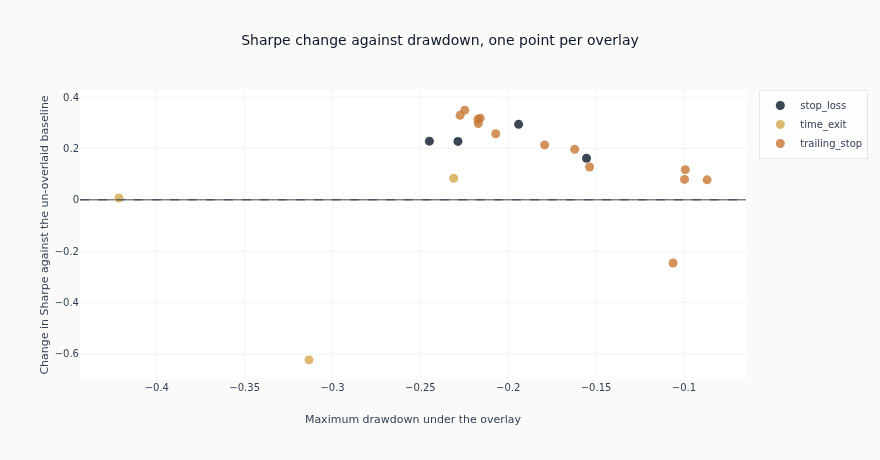

In [10]:
fig = go.Figure()
for risk_type in risk_df["risk_type"].unique().sort().to_list():
    subset = risk_df.filter(pl.col("risk_type") == risk_type)
    fig.add_trace(
        go.Scatter(
            x=subset["max_drawdown"].to_list(),
            y=subset["sharpe_delta"].to_list(),
            mode="markers",
            name=risk_type,
            text=subset["risk_name"].to_list(),
            hovertemplate="%{text}<br>drawdown %{x:.1%}<br>Sharpe change %{y:+.3f}<extra></extra>",
            marker=dict(size=9, opacity=0.8),
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_xaxes(title_text="Maximum drawdown under the overlay")
fig.update_yaxes(title_text="Change in Sharpe against the un-overlaid baseline")
fig.update_layout(
    title="Sharpe change against drawdown, one point per overlay",
    height=460,
    width=880,
    margin=dict(t=90),
)
_delta = risk_df["sharpe_delta"]
_dd = risk_df["max_drawdown"]
show_plotly_with_alt(
    fig,
    "Scatter of each risk overlay's change in Sharpe against the maximum drawdown it produced, one "
    "series per rule family, with a dashed line at no change. Counted from the frame: "
    f"{risk_df.height} overlays, Sharpe change from {_delta.min():+.3f} to {_delta.max():+.3f}, "
    f"drawdown from {_dd.min():.1%} to {_dd.max():.1%}, and "
    f"{int((_delta > 0).sum())} overlays above the baseline.",
)

## 5. What to notice

**A stop is a bet that the next move continues, placed by a strategy whose whole thesis is
monthly.** The signal says these funds are the ones to hold for the coming month. A rule that
closes one on day nine is overriding that signal with a different one - price action since entry
- and the grid above is the measurement of whether that different signal is worth listening to at
each threshold.

**A threshold below the ordinary intra-month movement of these funds is the one that hurts.** It
fires on almost every position, turning a monthly strategy into a series of truncated holds and
paying the round trip each time. Read the tightest rows of the table against the loosest: if the
ordering runs one way along the threshold, what the grid is measuring is how often the rule fires
rather than how well it selects what to exit.

**A rule that fires rarely is not thereby a rule that does nothing.** That is the assumption
worth checking against the table rather than carrying into it: a threshold reached by only a
handful of positions still removes those positions, and if the ones it removes are the ones that
went on to lose, a rule with very few triggers can move the Sharpe more than a rule with many.
What separates the two is not the trigger count but which positions the trigger caught, and the
drawdown column beside the Sharpe is where that shows.

**Calibrating from the adverse-excursion distribution is what makes a threshold about this
universe.** Three percent means one thing on a bond fund and another on a leveraged commodity
fund, and a single round number applied to both is really two different rules. A percentile of
the observed excursions is one rule.

**Read the change, not the level.** Every overlay here inherits a baseline that was already
positive, so a row with a good Sharpe may still be a rule that cost its strategy something. The
`sharpe_delta` column is the one that answers whether the rule earned its place.

**Known limitations.** The thresholds are evaluated on the same validation folds the strategies
were selected on, so an overlay that looks best here has been chosen on the same data twice over,
and nothing in this stage deflates for that. The MAE calibration reads excursions from the whole
price history rather than from a training window that precedes each fold. Portfolio-level limits
are declared empty for this case study, so nothing here says anything about them. And the holdout
is not consulted.

**Next**: [`18_strategy_analysis`](18_strategy_analysis.ipynb) reads the whole pipeline -
signal, allocation, costs and this overlay stage - as one progression, and is where the holdout
is finally opened.